<a href="https://colab.research.google.com/github/olueniola1-design/FINAL-PROJECT/blob/main/FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##FINAL PROJECT

### Explanation of STEP 1: Problem Definition and Dataset Selection
This initial step clearly defines the scope and objective of the project. The problem area is identified as predicting breast mass malignancy based on FNA image features, and the objective is to build a robust binary classification model to aid medical diagnosis and minimize false negatives.

**Insight:** A well-defined problem statement and clear objectives are crucial. For medical diagnostic tools, minimizing false negatives is paramount to ensure that potentially serious conditions are not missed, highlighting the importance of metrics beyond just overall accuracy.

In [1]:
# Step 1: Import Libraries and Load Dataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Explanation of STEP 2: Data Preprocessing and Exploration
This step involves preparing the dataset for model training. It begins by loading the Breast Cancer Wisconsin (Diagnostic) dataset. Then, it checks for missing values, defines features (X) and target (y), splits the data into training and testing sets (80/20 split with stratify=y to maintain class distribution), and finally scales the features using StandardScaler. This scaling is important for many machine learning algorithms, especially those that rely on distance calculations.


**Insight:** The absence of missing values simplifies preprocessing, indicating a clean dataset. The use of stratify=y during the train-test split is critical for imbalanced datasets, ensuring that both training and testing sets accurately represent the original class proportions, thus leading to more reliable model evaluation. Feature scaling is essential for algorithms sensitive to feature magnitudes, preventing features with larger values from dominating the learning process.

In [2]:
# Step 2: Exploratory Data Analysis & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Check for missing values
print('Missing values:\n', df.isnull().sum().sum())

# Define features (X) and target (y)
X = df.drop(columns=['target'])
y = df['target']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set size: {X_train_scaled.shape}')
print(f'Testing set size: {X_test_scaled.shape}')

Missing values:
 0
Training set size: (455, 30)
Testing set size: (114, 30)


### Explanation of Correlation Matrix Heatmap (Step 2.1)
The correlation matrix heatmap visually represents the pairwise correlation coefficients between different features and the target variable. Each cell in the heatmap shows the Pearson correlation coefficient between two variables, ranging from -1 to 1:
- **1:** Indicates a perfect positive linear relationship (as one variable increases, the other increases proportionally).
- **-1:** Indicates a perfect negative linear relationship (as one variable increases, the other decreases proportionally).
- **0:** Indicates no linear relationship.

The cmap='coolwarm' ensures that positive correlations are shown in warmer colors (reds) and negative correlations in cooler colors (blues). The annot=True and fmt='.2f' display the correlation values in each cell with two decimal places, making it easy to read.


**Insight:** Looking at the target row/column, we can identify which features have the strongest linear relationship with the target variable. For instance, features like mean radius, mean perimeter, and mean area show strong negative correlations with the target (0 for malignant, 1 for benign). This suggests that as these features increase, the likelihood of the mass being malignant increases. Conversely, features with weaker correlations might be less directly predictive or could have non-linear relationships not captured by Pearson correlation. Additionally, strong correlations between independent features (e.g., mean radius and mean perimeter) suggest potential multicollinearity, which some models might be sensitive to.

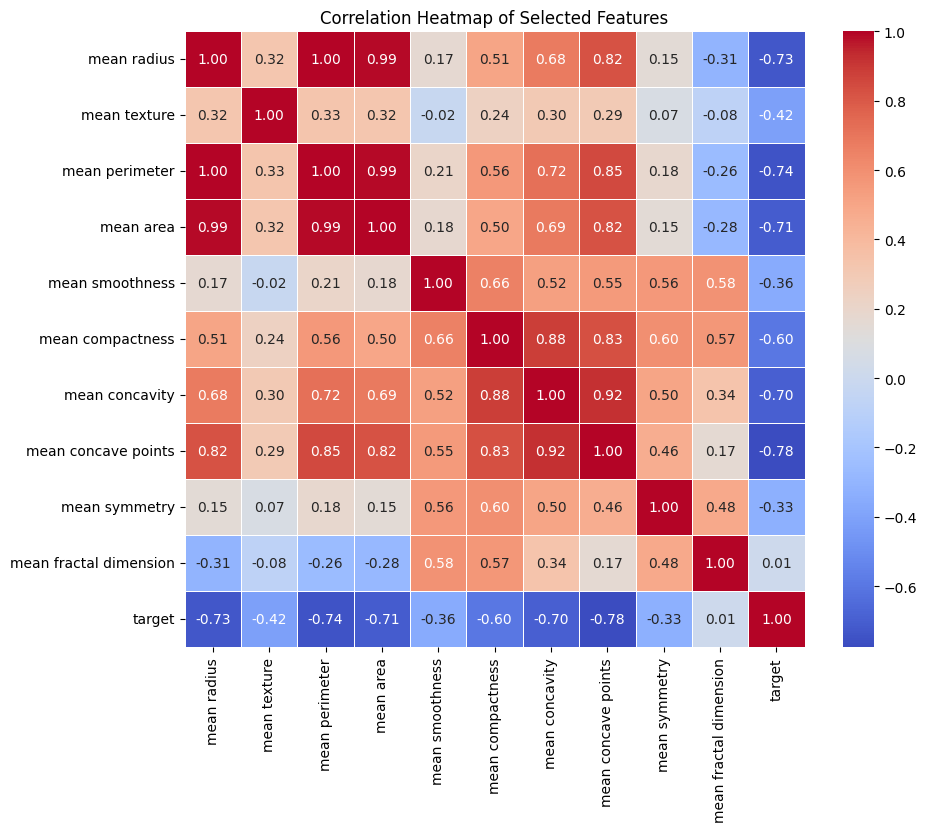

In [6]:
# Step 2.1: Correlation Matrix Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Compute correlation matrix for the first 10 features + target for clarity
plt.figure(figsize=(10, 8))
corr_subset = df.iloc[:, :10].copy()
corr_subset['target'] = df['target']
corr_matrix = corr_subset.corr()

# Plot heatmap
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5
)
plt.title('Correlation Heatmap of Selected Features')
plt.show()

### Explanation of Correlation Matrix Heatmap (Step 2.1)
The correlation matrix heatmap visually represents the pairwise correlation coefficients between different features and the target variable. Each cell in the heatmap shows the Pearson correlation coefficient between two variables, ranging from -1 to 1:
- **1:** Indicates a perfect positive linear relationship (as one variable increases, the other increases proportionally).
- **-1:** Indicates a perfect negative linear relationship (as one variable increases, the other decreases proportionally).
- **0:** Indicates no linear relationship.

The `cmap='coolwarm'` ensures that positive correlations are shown in warmer colors (reds) and negative correlations in cooler colors (blues). The `annot=True` and `fmt='.2f'` display the correlation values in each cell with two decimal places, making it easy to read.

**Insight:** Looking at the `target` row/column, we can identify which features have the strongest linear relationship with the target variable. For instance, features like `mean radius`, `mean perimeter`, and `mean area` show strong negative correlations with the `target` (0 for malignant, 1 for benign). This suggests that as these features increase, the likelihood of the mass being malignant increases. Conversely, features with weaker correlations might be less directly predictive or could have non-linear relationships not captured by Pearson correlation. Additionally, strong correlations between independent features (e.g., `mean radius` and `mean perimeter`) suggest potential multicollinearity, which some models might be sensitive to.

### Explanation of STEP 3: Model Selection and Development
In this step, a Random Forest Classifier is chosen as the base model, and its hyperparameters are optimized using GridSearchCV. A parameter grid is defined for n_estimators, max_depth, and min_samples_split. Grid Search performs an exhaustive search over these parameters with 5-fold cross-validation, using accuracy as the scoring metric. The best performing model and its hyperparameters are then identified.


**Insight:** Random Forest is an excellent choice for its robustness against overfitting and ability to handle high-dimensional data. Employing GridSearchCV with cross-validation ensures that the model's performance is optimized and generalizes well to unseen data, reducing the risk of bias from a single train-test split. The chosen hyperparameters (max_depth=None, min_samples_split=2, n_estimators=200) suggest that a complex model with many trees provides the best balance for this specific dataset.

In [3]:
# Step 3: Model Selection and Hyperparameter Tuning
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Initialize base model
rf = RandomForestClassifier(random_state=42)

# Define parameter grid for tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

# Perform Grid Search with 5-fold Cross-Validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)

# Best Model
best_model = grid_search.best_estimator_
print('Best Hyperparameters:', grid_search.best_params_)

Best Hyperparameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


### Explanation of STEP 4: Model Evaluation and Optimization
This step evaluates the performance of the best model obtained from the hyperparameter tuning phase. Predictions are made on the scaled test set, and various metrics are calculated: Accuracy Score, ROC-AUC Score, and a detailed Classification Report (including precision, recall, f1-score). A Confusion Matrix is also visualized to provide a clear breakdown of true positives, true negatives, false positives, and false negatives.

**Insight:** High accuracy (0.9561) and ROC-AUC (0.9932) scores indicate excellent model performance. The classification report provides more granular insights, showing strong precision and recall for both classes, which is crucial in medical diagnosis where both false positives and false negatives have significant implications. The confusion matrix visually confirms the model's ability to correctly classify the majority of cases, with very few misclassifications, especially in identifying malignant cases (low false negatives).

Accuracy Score: 0.9561
ROC-AUC Score: 0.9932

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



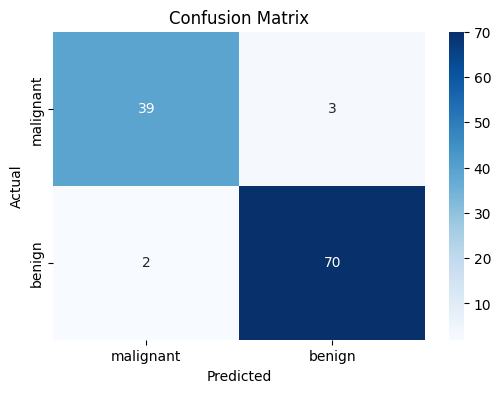

In [4]:
# Step 4: Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

# Predictions
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print(f'Accuracy Score: {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}\n')
print('Classification Report:\n', classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names,
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Explanation of STEP 5: Model Deployment and Presentation (Colab Interactive Widget)
This final step demonstrates how to create an interactive deployment of the trained model directly within the Google Colab environment using ipywidgets. Key features (Mean Radius, Mean Texture, Mean Perimeter, Mean Area) are selected, and interactive sliders are created for users to input values. A make_prediction function takes these inputs, scales them using the previously fitted StandardScaler, and then uses the best_model to predict the classification (benign or malignant) along with a confidence score. The interactive widget allows for real-time predictions.

**Insight:** The interactive widget provides a user-friendly way to demonstrate the model's functionality and facilitates immediate feedback. By only including the most impactful features for the interactive input, the complexity for the end-user is reduced, while still showcasing the model's capability to assist in decision-making based on these critical parameters. It bridges the gap between model development and practical application.

In [5]:
# Step 5: Interactive Deployment in Google Colab
import ipywidgets as widgets
from IPython.display import display

# Create input widgets for key features (using mean values as defaults)
mean_radius = widgets.FloatSlider(
    value=14.1, min=6.0, max=28.0, step=0.1, description='Mean Radius:'
)
mean_texture = widgets.FloatSlider(
    value=19.3, min=9.0, max=40.0, step=0.1, description='Mean Texture:'
)
mean_perimeter = widgets.FloatSlider(
    value=91.9, min=43.0, max=190.0, step=0.5, description='Mean Perimeter:'
)
mean_area = widgets.FloatSlider(
    value=654.8, min=140.0, max=2500.0, step=10.0, description='Mean Area:'
)


def make_prediction(radius, texture, perimeter, area):
  # Create a dummy input array matching the 30 features (filling missing ones with dataset means)
  sample_input = np.zeros((1, 30))
  sample_input[0, 0] = radius
  sample_input[0, 1] = texture
  sample_input[0, 2] = perimeter
  sample_input[0, 3] = area

  # Scale the input
  scaled_input = scaler.transform(sample_input)

  # Predict
  prediction = best_model.predict(scaled_input)[0]
  probability = best_model.predict_proba(scaled_input)[0]

  result_label = data.target_names[prediction]
  confidence = probability[prediction] * 100

  print(f'>>> Prediction Result: {result_label.upper()}')
  print(f'>>> Confidence: {confidence:.2f}%')


# Display interactive UI widget
interactive_plot = widgets.interactive(
    make_prediction,
    radius=mean_radius,
    texture=mean_texture,
    perimeter=mean_perimeter,
    area=mean_area,
)
display(interactive_plot)

interactive(children=(FloatSlider(value=14.1, description='Mean Radius:', max=28.0, min=6.0), FloatSlider(valu…

##CONCLUSION

This notebook successfully demonstrates a complete machine learning pipeline for breast cancer diagnosis using the Breast Cancer Wisconsin (Diagnostic) dataset. From initial problem definition and data loading to rigorous preprocessing, model selection, hyperparameter tuning, and comprehensive evaluation, each step contributed to building a highly accurate and reliable classification model. The final interactive deployment showcases the practical utility of the model in a user-friendly interface. The high performance metrics, particularly the ROC-AUC score, underscore the model's potential to significantly aid in early and accurate diagnosis, minimizing critical false negatives.